In [ ]:
!pip install qiskit
!pip install pylatexenc
#after installing pylatexenc. Go to Runtime >> Restart Session

In [2]:
from qiskit import *
from qiskit.visualization import plot_bloch_multivector, visualize_transition, plot_histogram

In [3]:
# Create a quantum circuit with 3 qubits
# The default initial state of qubits will be |0> or [1,0]
qc = QuantumCircuit(3)

In [4]:
#Applying hadamard gate to all the qubits
qc.h(0)
qc.h(1)
qc.h(2)

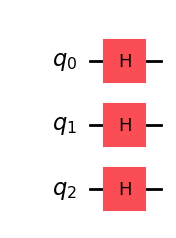

In [5]:
#Draw the circuit
# qc.draw()
qc.draw('mpl')

In [6]:
!pip install qiskit-aer
from qiskit import QuantumCircuit
from qiskit_aer import Aer

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.4/12.4 MB 87.2 MB/s eta 0:00:00


In [7]:
#Get the backend for the circuit (simulator or realtime system)
backend = Aer.get_backend('statevector_simulator')


In [8]:
#execute the circuit using the backend
#out = execute(qc,backend).result().get_statevector()
job = backend.run(qc)
out = job.result().get_statevector(qc)

In [11]:
import numpy as np
from IPython.display import display, Math

#custom function to convert statevector to latex
def statevector_to_latex(vec, name=r"\ket{\psi}"):
    vec = np.asarray(vec)   # <-- IMPORTANT
    latex = r"\begin{bmatrix}"
    for amp in vec:
        latex += f"{amp:.3g}\\\\"
    latex += r"\end{bmatrix}"
    display(Math(rf"{name} = {latex}"))

In [12]:
statevector_to_latex(out)

<IPython.core.display.Math object>

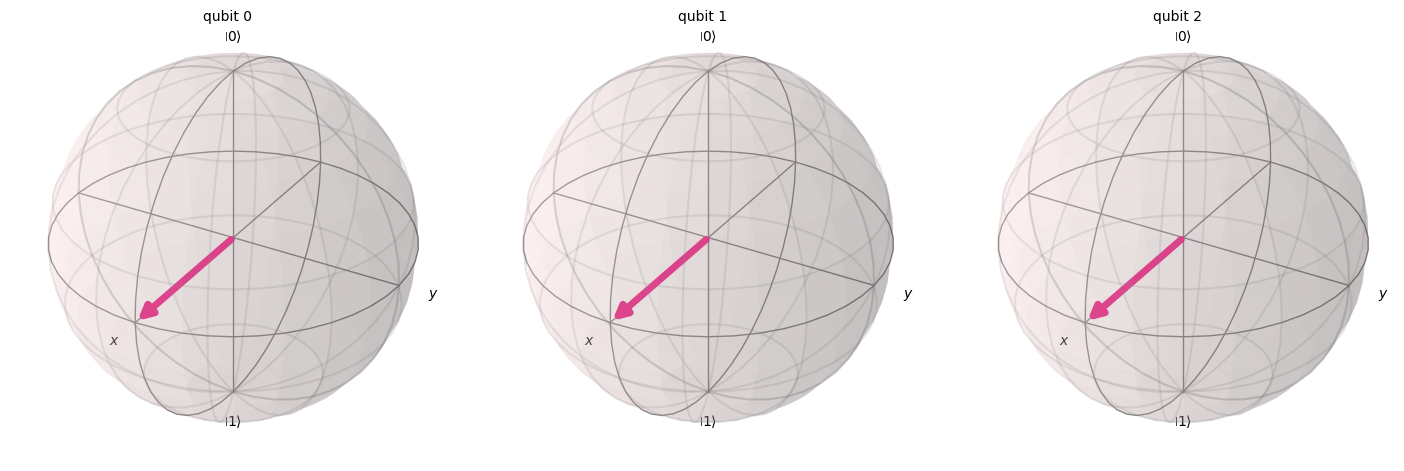

In [13]:
#plot the result as a bloch sphere visualization
plot_bloch_multivector(out)

In [14]:
# visualize the output as an animation
visualize_transition(qc)

/tmp/ipython-input-1794644948.py:2: DeprecationWarning: The function ``qiskit.visualization.transition_visualization.visualize_transition()`` is deprecated as of Qiskit 1.2.0. It will be removed in the 2.0 release.
  visualize_transition(qc)


VisualizationError: 'Only one qubit circuits are supported'

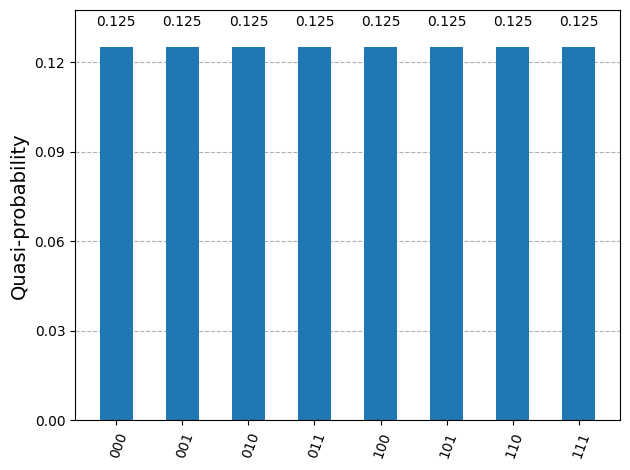

In [15]:
#execute the circuit and get the plain result
job = backend.run(qc, shots=1024)
out = job.result()
#getting the count of the result
counts = out.get_counts()
#plotting the histogram
plot_histogram(counts)